# Librerías

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("stopwords")
stop_words = set(stopwords.words("spanish"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\javie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Ejercicio 1

In [2]:
videos = pd.read_csv("datos/youtube_videos.csv")
comentarios = pd.read_csv("datos/youtube_comments.csv")

videos.shape
comentarios.shape

videos.head()
comentarios.head()

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@iamjimalesssa,hace 1 año,4,0,False,NaN
3,j43HgwYFKfk,Ugw0xgUc2ISpBr5_T654AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@gonzalo6075,UCkbsS_3D-pvg1iHOld9uvIg,Veremos a este mafioso de Mazariegos en la cár...,@quorumgt/videos,channel,quorum_complete_comments.csv | youtube_guatema...,/@gonzalo6075,hace 1 año,,0,False,NaN
4,OkXlHx0hx-8,Ugw1ZzA21njWhaqQQTh4AaABAg,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,@luisroldan7374,UCOLHH4ZpMxPYF-Q6e6wvn5A,eso es para que salga de USA por su propio pie...,guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@luisroldan7374,hace 1 día,2,1,False,NaN


In [5]:
videos.columns
comentarios.columns

Index(['video_id', 'comment_id', 'video_title', 'channel_name', 'channel_id',
       'author_name', 'author_channel_id', 'text', 'source_query',
       'source_group', 'dataset_sources', 'author_handle', 'published_text',
       'like_count_text', 'reply_count', 'is_pinned', 'viewer_rating'],
      dtype='object')

En el dataset de videos, cada fila representa un video y video_id es el ID único. En el dataset de comentarios, cada fila representa un comentario y comment_id es el ID único. video_id funciona como llave foránea para asociar un comentario con un video. author_channel_id y chanel_id identifican al dueño de un canal.

La relación entre las entidades es que un canal puede subir uno o más videos. Cada video se identifica como video_id y se relaciona con channel_id. Los comentarios pertenecen a un video identificado con video_id. Cada comentario se identifica con comment_id, y author_channel_id identifica al autor del comentario. Cada video tiene una categoría, la variable category describe la categoría que youtube asigna. Finalmente, source_query indica qué consulta llevó a encontrar el video durante la recolección de datos.

In [6]:
datos = comentarios.merge(
    videos,
    on="video_id",
    how="left",
    suffixes=("_comentario", "_video"),
    indicator=True
)

datos["_merge"].value_counts()

asociados = (datos["_merge"] == "both").sum()
no_asociados = (datos["_merge"] == "left_only").sum()

print("Total de comentarios:", len(comentarios))
print("Comentarios asociados:", asociados)
print("Comentarios no asociados:", no_asociados)

print(
    "Porcentaje asociado:",
    round(asociados / len(comentarios) * 100, 2),
    "%"
)

Total de comentarios: 406
Comentarios asociados: 406
Comentarios no asociados: 0
Porcentaje asociado: 100.0 %


# Ejercicio 2

Dimensiones de videos: (293, 20)
Dimensiones de comentarios: (406, 17)
Dimensiones después de la integración: (406, 37)
VIDEOS
video_id               object
title                  object
channel_name           object
channel_id             object
source_query           object
source_group           object
dataset_sources        object
channel_handle         object
published_time         object
view_count_text        object
description_snippet    object
video_url              object
query_hits             object
keywords               object
description            object
view_count              int64
publish_date           object
upload_date            object
category               object
owner_handle           object
dtype: object

COMENTARIOS
video_id              object
comment_id            object
video_title           object
channel_name          object
channel_id            object
author_name           object
author_channel_id     object
text                  object
source_query  

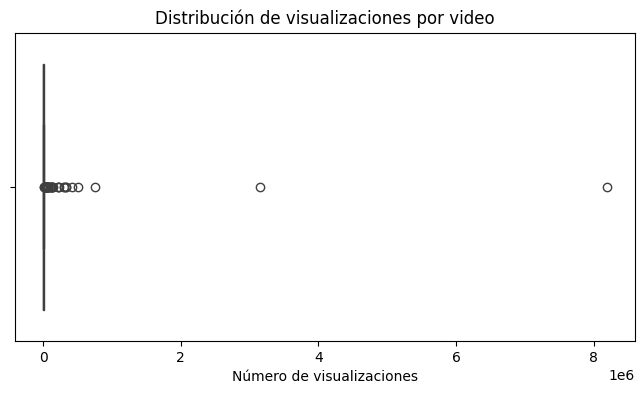

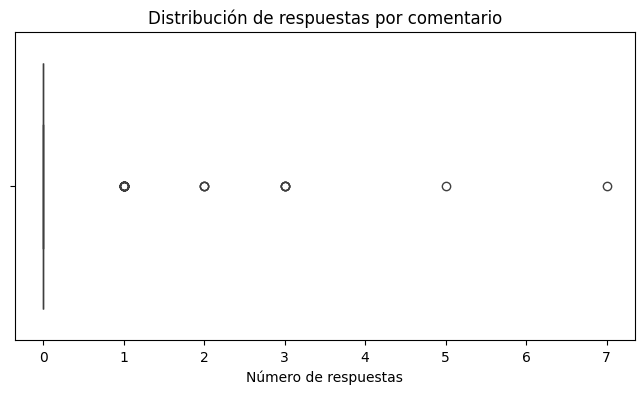

,nombres,handles
channel_id,,


In [11]:
# Dimensiones
print("Dimensiones de videos:", videos.shape)
print("Dimensiones de comentarios:", comentarios.shape)
print("Dimensiones después de la integración:", datos.shape)

# Tipos de variables
print("VIDEOS")
print(videos.dtypes)

print("\nCOMENTARIOS")
print(comentarios.dtypes)

# Valores faltantes
def resumen_faltantes(df):
    return pd.DataFrame({
        "faltantes": df.isna().sum(),
        "porcentaje": (df.isna().mean() * 100).round(2)
    }).sort_values(
        "porcentaje",
        ascending=False
    )
resumen_faltantes(videos)
resumen_faltantes(comentarios)

print("Filas duplicadas en videos:")
print(videos.duplicated().sum())

print("\nFilas duplicadas en comentarios:")
print(comentarios.duplicated().sum())

print(
    "Textos de comentarios duplicados:",
    comentarios["text"].duplicated().sum()
)

constantes_videos = [
    columna
    for columna in videos.columns
    if videos[columna].nunique(dropna=False) <= 1
]

constantes_videos

constantes_comentarios = [
    columna
    for columna in comentarios.columns
    if comentarios[columna].nunique(dropna=False) <= 1
]

constantes_comentarios

videos["view_count"].describe()

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=videos["view_count"]
)

plt.title("Distribución de visualizaciones por video")
plt.xlabel("Número de visualizaciones")
plt.show()

comentarios["reply_count"].describe()

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=comentarios["reply_count"]
)

plt.title("Distribución de respuestas por comentario")
plt.xlabel("Número de respuestas")
plt.show()

comentarios.nlargest(
    10,
    "reply_count"
)[
    ["text", "author_name", "reply_count"]
]

consistencia_canales = (
    videos.groupby("channel_id")
    .agg(
        nombres=("channel_name", "nunique"),
        handles=("channel_handle", "nunique")
    )
)

consistencia_canales.describe()


consistencia_canales[
    (consistencia_canales["nombres"] > 1) |
    (consistencia_canales["handles"] > 1)
]

En la revisión inicial se puede observar que no hay valores faltantes en las variables que serán importantes para el análisis, y que las dimensiones son correctas y tienen sentido después de haber asociado los comentarios y los videos. Aunque en los diagramas parece haber valores atípicos, considerando que es un dataset de videos y comentarios estos pueden hablar de la popularidad de los videos, por lo que de momento no serán eliminados.

Algunas variables requieren tratamiento especial, como viewer_rating, esta está vacía en todos los comentarios, por lo que no se utilizará. is_pinned es False en todos los comentarios, así que no se utilizará. published_time y published_text muestran tiempos como "hace 2 días", que no pueden interpretarse literalmente, así que en vez de utilizarlas para análisis temporal se utilizará publish_date. reply_count solo indica cuántas respuestas tiene un comentario, pero no quién respondió, así que no se utilizará para construir relaciones entre autores.

In [12]:
# normalizar ID
videos["video_id"] = videos["video_id"].astype(str).str.strip()
videos["channel_id"] = videos["channel_id"].astype(str).str.strip()

comentarios["video_id"] = comentarios["video_id"].astype(str).str.strip()
comentarios["comment_id"] = comentarios["comment_id"].astype(str).str.strip()

# normalizar nombres y handles
videos["channel_name"] = videos["channel_name"].astype("string").str.strip()
videos["channel_handle"] = videos["channel_handle"].astype("string").str.strip()

comentarios["author_name"] = comentarios["author_name"].astype("string").str.strip()
comentarios["author_handle"] = comentarios["author_handle"].astype("string").str.strip()

# Comprobación
print("video_id faltantes:", videos["video_id"].isna().sum())
print("channel_id faltantes:", videos["channel_id"].isna().sum())

print("comment_id faltantes:", comentarios["comment_id"].isna().sum())
print(
    "author_channel_id faltantes:",
    comentarios["author_channel_id"].isna().sum()
)

video_id faltantes: 0
channel_id faltantes: 0
comment_id faltantes: 0
author_channel_id faltantes: 0


Se normalizaron los ID para garantizar que no haya problemas con el análisis más adelante, los identificadores mencionados anteriormente seguirán siendo utilizados. Los nombres y handles también se normalizaron, pero se conservó su formato originla para poder usarlos como atributos descriptivos.

In [24]:
comentarios["like_count"] = pd.to_numeric(
    comentarios["like_count_text"],
    errors="coerce"
)

comentarios[
    ["like_count_text", "like_count"]
].head(20)

print("Valores no convertidos:")
print(comentarios["like_count"].isna().sum())

comentarios["texto_original"] = comentarios["text"].copy()
comentarios["texto_limpio"] = comentarios["text"].copy()

comentarios[
    ["text", "texto_original", "texto_limpio"]
].head()

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .str.lower()
)
comentarios[
    ["texto_original", "texto_limpio"]
].head(10)

tiene_url = comentarios["texto_original"].str.contains(
    r"https?://\S+|www\.\S+",
    regex=True,
    na=False
)

print("Comentarios con URL:", tiene_url.sum())

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .str.replace(
        r"https?://\S+|www\.\S+",
        "",
        regex=True
    )
)

comentarios["hashtags"] = comentarios["texto_original"].str.findall(
    r"#\w+"
)

comentarios[
    ["texto_original", "hashtags"]
].head(10)

comentarios["tiene_hashtag"] = (
    comentarios["hashtags"].str.len() > 0
)

print(
    "Comentarios con hashtags:",
    comentarios["tiene_hashtag"].sum()
)

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .str.replace(
        r"[^\w\s]",
        " ",
        regex=True
    )
)

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .apply(
        lambda texto: " ".join(
            palabra
            for palabra in texto.split()
            if palabra not in stop_words
        )
    )
)

modificados = (
    comentarios["texto_original"] != comentarios["texto_limpio"]
).sum()

print("Total de comentarios:", len(comentarios))
print("Textos modificados:", modificados)
print(
    "Porcentaje modificado:",
    round(modificados / len(comentarios) * 100, 2),
    "%"
)

vacios_antes = (
    comentarios["texto_original"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Textos vacíos antes:", vacios_antes)

vacios_despues = (
    comentarios["texto_limpio"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Textos vacíos después:", vacios_despues)

duplicados_antes = comentarios[
    "texto_original"
].duplicated().sum()

print("Textos duplicados antes:", duplicados_antes)

duplicados_despues = comentarios[
    "texto_limpio"
].duplicated().sum()

print("Textos duplicados después:", duplicados_despues)

Valores no convertidos:
189
Comentarios con URL: 1
Comentarios con hashtags: 1
Total de comentarios: 406
Textos modificados: 402
Porcentaje modificado: 99.01 %
Textos vacíos antes: 0
Textos vacíos después: 5
Textos duplicados antes: 2
Textos duplicados después: 10


La limpieza modificó la mayoría de los comentarios debido a la normalización de mayúsculas, eliminación de elementos no textuales y stopwords. Se comparó además la cantidad de textos vacíos y duplicados antes y después del procesamiento para verificar que la limpieza no eliminara una cantidad importante de información y para identificar comentarios que se volvieron equivalentes después de la normalización.

# Ejercicio 3

3.1 RESUMEN GENERAL
Videos: 293
Canales: 97
Comentarios: 406
Autores únicos: 332

Top 10 canales por número de videos:


channel_id                channel_name                         
UC-ZtFBHzgkYFh7whZkuR_Ag  Gobierno de la República de Guatemala    32
UCXa6LVjBzUtmcM3cwbd9e2w  Municipalidad de Guatemala               27
UCE4rsXcgDb6e1-a9iTbWzfg  Quorum                                   18
UCEepOY2svuxbsJ-zsAPT9Fg  PrensaLibreOficial                       17
UC8u2nvyHewt-mjdWSj0HJmQ  Ministerio de Gobernación                14
UCaivrAhro2BpsJdrPe-IyRg  Diario de Centro América                 11
UCAutgrPkiLhZxTB-Ujje1fw  CIV -Ministerio de Comunicaciones        11
UCW_PHqwqCCalvQGOEsVU0jw  Concejales de Oposición - Muni Guate     10
UCHsYnV67K3J0yJ4QeciVCww  PNCdeGuatemala                           10
UC6SA1dVHvAkc6yNS_t5cbGw  Conred                                    8
dtype: int64

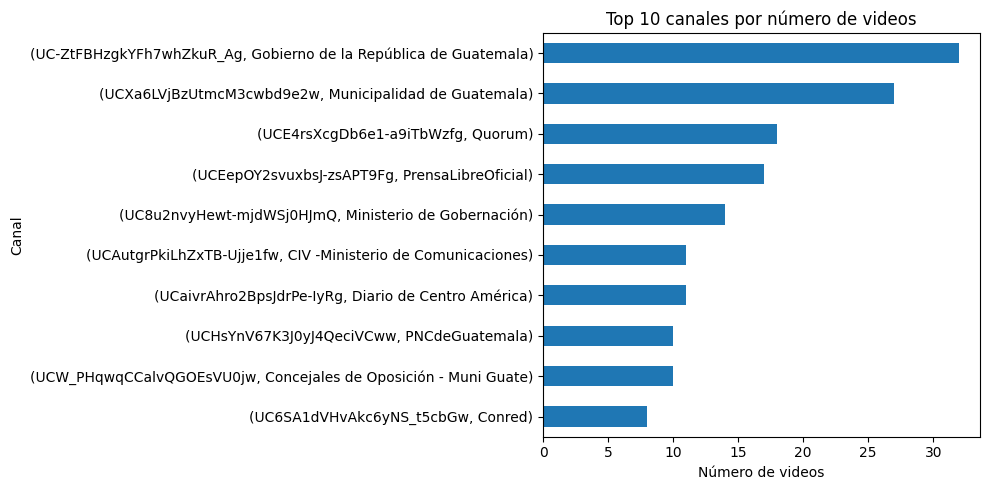


Participación por video:

Top 10 videos con mayor cantidad de comentarios:


,,comentarios,autores_unicos
video_id,video_title,,
n8iP75gIpmw,Qué rico come tu diputado,161,128
j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,50,49
6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,45,32
lj983NWyAQY,Plan 2032 Ciudad de Guatemala,25,25
PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,25,19
OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,25,18
yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,16,16
06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,14,13
ndAZjHqzzT8,Internet: escoger el menos malo,12,10


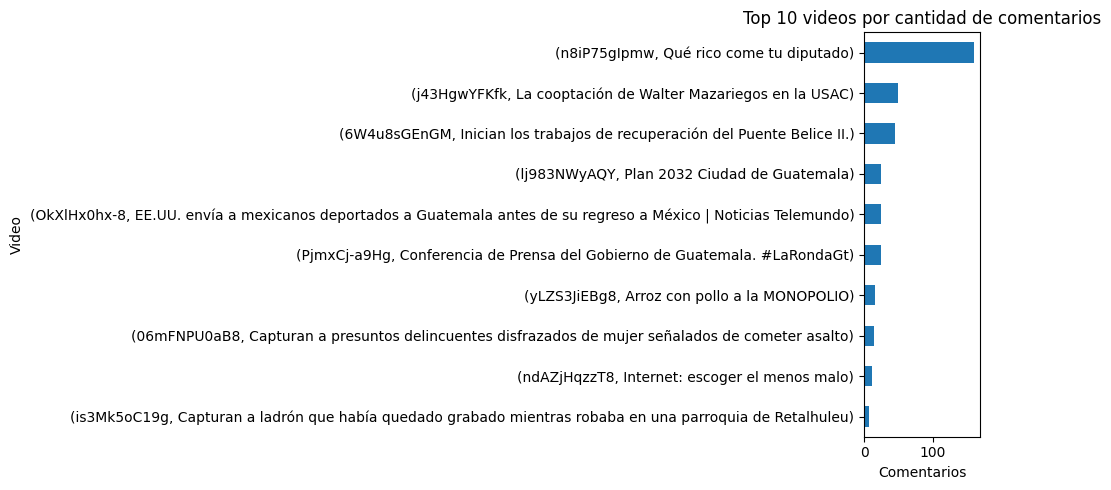


Estadísticas de visualizaciones:


count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64

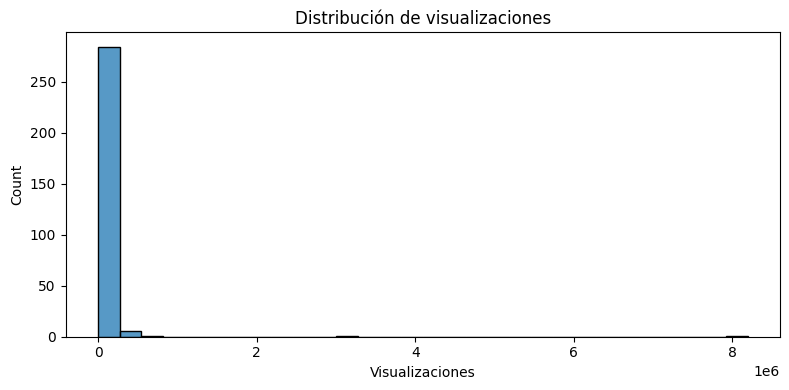


Top 10 videos con más visualizaciones:


,title,channel_name,view_count
148,"Los ALUCINANTES autobuses de Guatemala | ""Burras""",Luisito Comunica,8190449
245,🚫LOS FAMOSOS BUSES ESMERALDA los mas RÁPIDOS D...,De todo Gt,3152619
113,🇬🇹HISTORIA de GUATEMALA en 17 minutos🇬🇹 - El M...,El Mapa de Sebas,749356
56,Este BUS me LLEVO a UN PARAISO EN GUATEMALA,De todo Gt,504374
126,✅ ASÍ es una EXHIBICION DE BUSES EN GUATEMALA,De todo Gt,424874
180,Sonido de trafico y ciudad 💤 ruido de calle pa...,Ambient Sound Explorer,330057
159,ME quité el MIEDO de viajar en los buses de GU...,De todo Gt,329489
182,Tercer Informe General de la República,Gobierno de Guatemala,305269
239,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,304089
176,Piloto de tráiler accidentado en ruta al Atlán...,PrensaLibreOficial,233632



Estadísticas de respuestas:


count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64

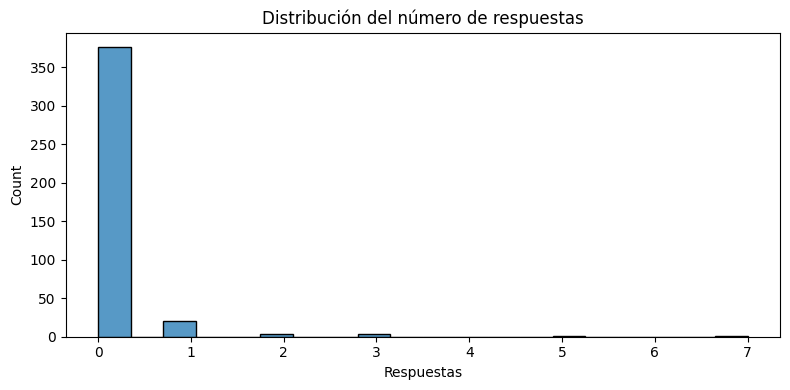


Estadísticas de likes:


count    217.000000
mean      10.714286
std       41.340405
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max      405.000000
Name: like_count, dtype: float64

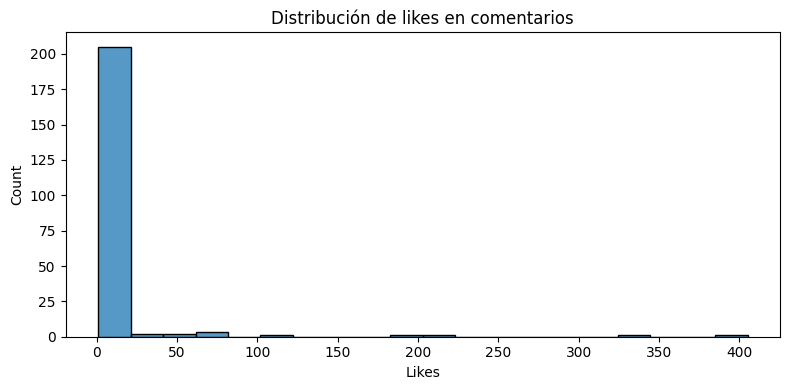


Categorías:


category
News & Politics          138
People & Blogs            66
Entertainment             48
Education                 19
Travel & Events            8
Science & Technology       6
Nonprofits & Activism      3
Film & Animation           2
Comedy                     1
Sports                     1
Music                      1
Name: count, dtype: int64

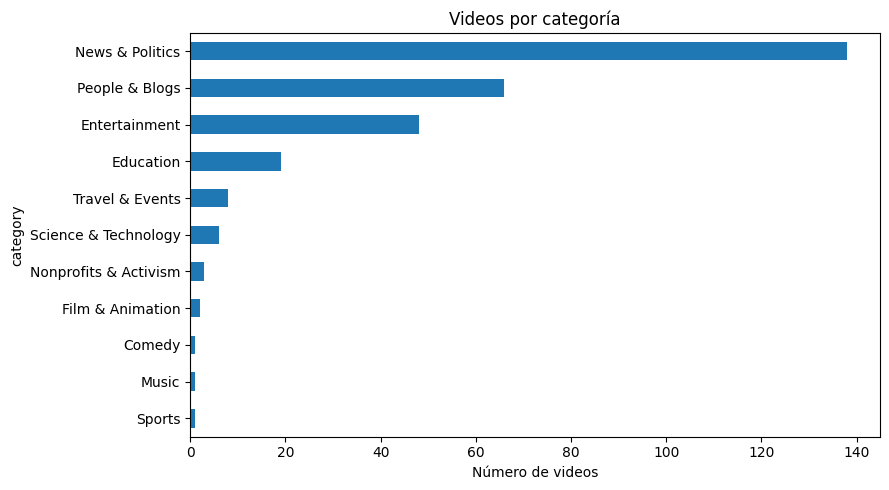


Consultas de búsqueda más frecuentes:


source_query
Municipalidad de Guatemala                20
Gobierno de Guatemala                     18
@GobiernodelaRepublicadeGuatema           18
@GobiernodeGuatemala                      17
guatemala noticias                        16
Ministerio de Comunicaciones Guatemala    16
@MunicipalidaddeGuatemala-1551            16
Gobierno de la República de Guatemala     15
PMT Guatemala                             15
Conred Guatemala                          15
Provial Guatemala                         13
guatemala trafico                         13
guatemala transporte                      13
Policia Nacional Civil Guatemala          13
guatemala lluvias                         12
Name: count, dtype: int64

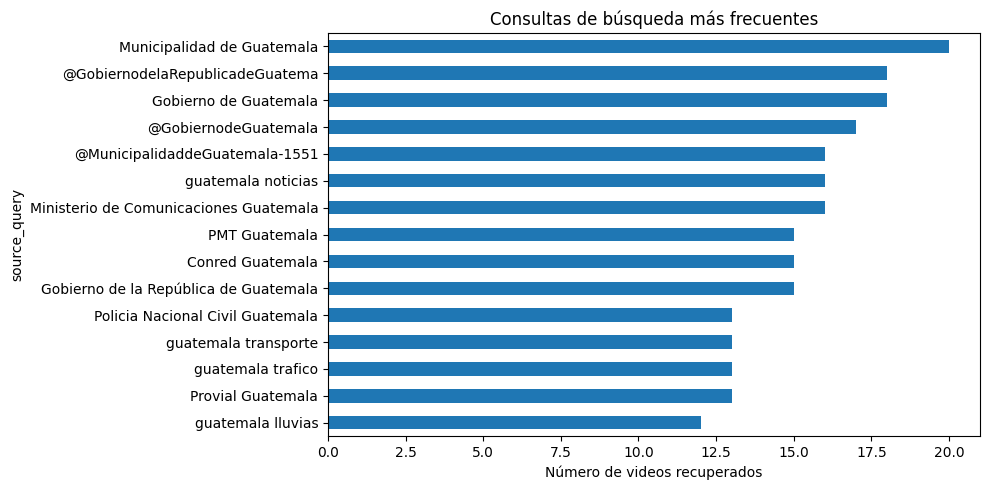


Hashtags más frecuentes:


,hashtag,frecuencia
0,#ineptobran,1


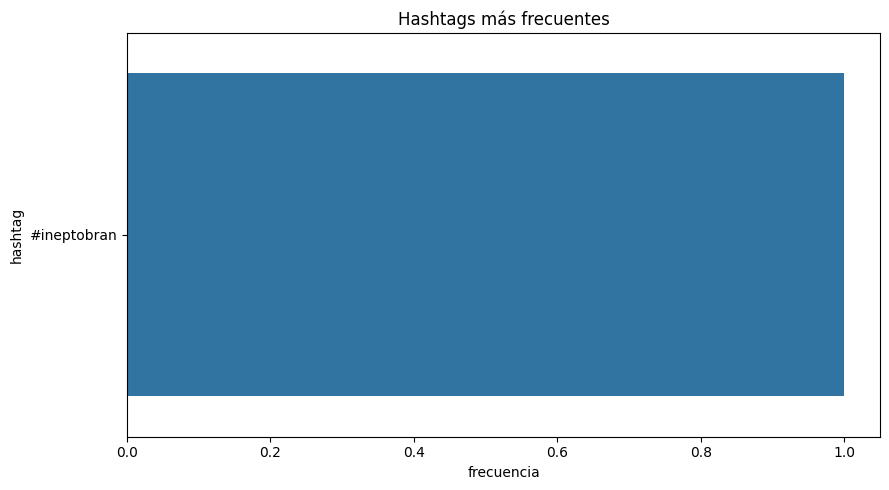


Palabras más frecuentes:


,palabra,frecuencia
0,si,74
1,pueblo,56
2,guatemala,52
3,dinero,34
4,solo,33
5,presidente,32
6,país,31
7,trabajo,30
8,diputados,28
9,corruptos,24


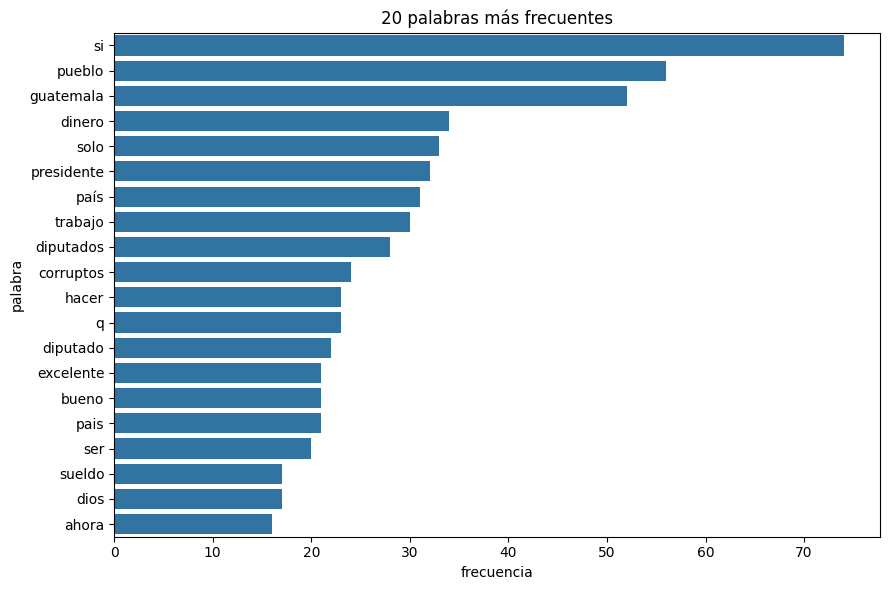


Bigramas más frecuentes:


,bigrama,frecuencia
94,presidente bernardo,9
15,bernardo arevalo,8
27,ciudad guatemala,6
17,bla bla,5
83,nery rodas,5
87,pacto corruptos,5
22,busquen trabajo,4
28,comida nadie,4
44,dinero pueblo,4
74,lleva años,4


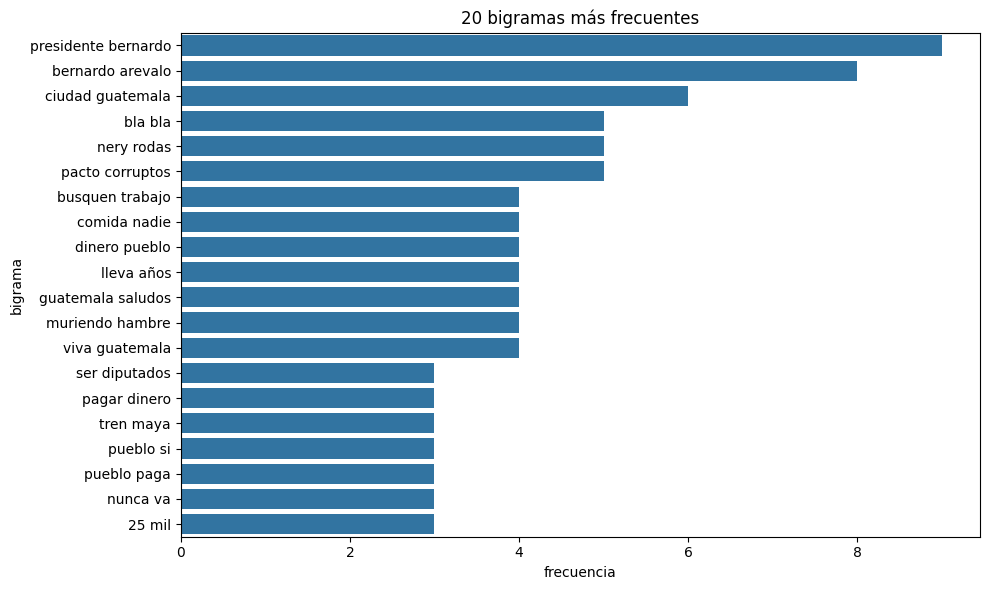

Top 1 videos concentran 39.66% de los comentarios
Top 1 canales concentran 63.05% de los comentarios
Top 5 videos concentran 75.37% de los comentarios
Top 5 canales concentran 96.06% de los comentarios
Top 10 videos concentran 93.60% de los comentarios
Top 10 canales concentran 100.00% de los comentarios


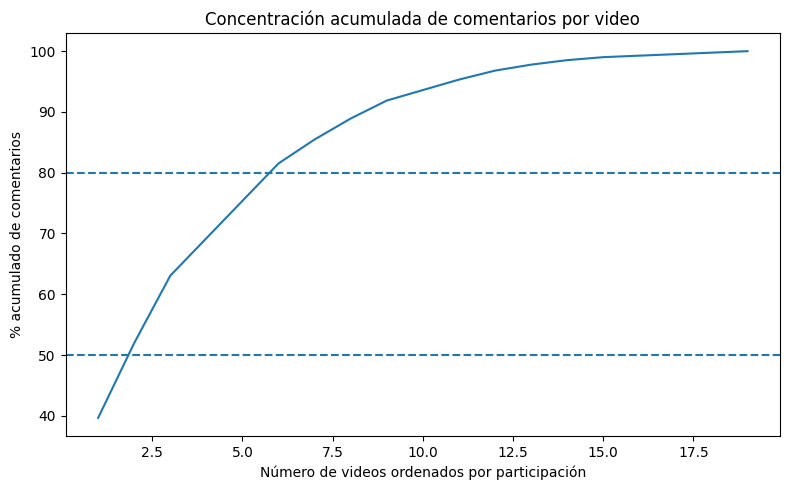


Correlación entre visualizaciones y comentarios observados:


,view_count,comentarios_observados
view_count,1.000000,-0.008393
comentarios_observados,-0.008393,1.000000


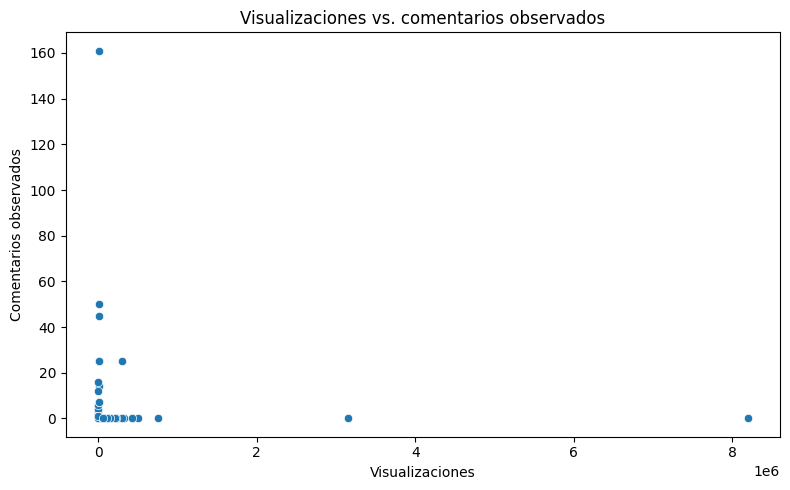


Videos con mayor participación observada:


,title,channel_name,view_count,comentarios_observados
246,Qué rico come tu diputado,Quorum,11775,161.0
229,La cooptación de Walter Mazariegos en la USAC,Quorum,10156,50.0
38,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,11670,45.0
130,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,14200,25.0
136,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,3628,25.0
239,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,304089,25.0
289,Arroz con pollo a la MONOPOLIO,Quorum,1954,16.0
4,Capturan a presuntos delincuentes disfrazados ...,Noti7,6692,14.0
250,Internet: escoger el menos malo,Quorum,717,12.0
197,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial,5469,7.0



Canales con más comentarios:


channel_id                channel_name                         
UCE4rsXcgDb6e1-a9iTbWzfg  Quorum                                   256
UC-ZtFBHzgkYFh7whZkuR_Ag  Gobierno de la República de Guatemala     70
UCRwA1NUcUnwsly35ikGhp0A  Noticias Telemundo                        25
UCXa6LVjBzUtmcM3cwbd9e2w  Municipalidad de Guatemala                25
UCVpSRoZgngfSL03Nlbjtq9A  Noti7                                     14
UCEepOY2svuxbsJ-zsAPT9Fg  PrensaLibreOficial                         7
UCt5Dw7ePnn0AqPqRF8Xpjkw  TN23 Guatemala                             7
UCdSVqHGHzyMTXSafUHY-e-w  Noticiero Guatevisión 13 Hrs.              2
dtype: int64


Autores que comentaron en más videos:


...

,total_comentarios,videos_distintos
total_comentarios,1.000000,0.349127
videos_distintos,0.349127,1.000000



2. ¿Los comentarios con más likes reciben también más respuestas?


,like_count,reply_count
like_count,1.000000,0.549087
reply_count,0.549087,1.000000



3. ¿Qué categorías presentan mayor participación observada?


,comentarios,autores
category,,
News & Politics,335,283
Entertainment,70,50
Nonprofits & Activism,1,1


In [26]:

print("3.1 RESUMEN GENERAL")

n_videos = videos["video_id"].nunique()
n_canales = videos["channel_id"].nunique()
n_comentarios = comentarios["comment_id"].nunique()
n_autores = comentarios["author_channel_id"].nunique()

print("Videos:", n_videos)
print("Canales:", n_canales)
print("Comentarios:", n_comentarios)
print("Autores únicos:", n_autores)


videos_por_canal = (
    videos.groupby(["channel_id", "channel_name"])
    .size()
    .sort_values(ascending=False)
)

print("\nTop 10 canales por número de videos:")
display(videos_por_canal.head(10))

plt.figure(figsize=(10, 5))
videos_por_canal.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 canales por número de videos")
plt.xlabel("Número de videos")
plt.ylabel("Canal")
plt.tight_layout()
plt.show()

print("\nParticipación por video:")
participacion_video = (
    comentarios.groupby(["video_id", "video_title"])
    .agg(
        comentarios=("comment_id", "count"),
        autores_unicos=("author_channel_id", "nunique")
    )
    .sort_values("comentarios", ascending=False)
)

print("\nTop 10 videos con mayor cantidad de comentarios:")
display(participacion_video.head(10))

plt.figure(figsize=(10, 5))
participacion_video["comentarios"].head(10).sort_values().plot(
    kind="barh"
)
plt.title("Top 10 videos por cantidad de comentarios")
plt.xlabel("Comentarios")
plt.ylabel("Video")
plt.tight_layout()
plt.show()

# VISUALIZACIONES

print("\nEstadísticas de visualizaciones:")
display(videos["view_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(videos["view_count"], bins=30)
plt.title("Distribución de visualizaciones")
plt.xlabel("Visualizaciones")
plt.tight_layout()
plt.show()

print("\nTop 10 videos con más visualizaciones:")
display(
    videos.nlargest(10, "view_count")[
        ["title", "channel_name", "view_count"]
    ]
)

# RESPUESTAS

print("\nEstadísticas de respuestas:")
display(comentarios["reply_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(comentarios["reply_count"], bins=20)
plt.title("Distribución del número de respuestas")
plt.xlabel("Respuestas")
plt.tight_layout()
plt.show()

# LIKES

print("\nEstadísticas de likes:")
display(comentarios["like_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(comentarios["like_count"].dropna(), bins=20)
plt.title("Distribución de likes en comentarios")
plt.xlabel("Likes")
plt.tight_layout()
plt.show()

# CATEGORIAS

categorias = videos["category"].value_counts()

print("\nCategorías:")
display(categorias)

plt.figure(figsize=(9, 5))
categorias.sort_values().plot(kind="barh")
plt.title("Videos por categoría")
plt.xlabel("Número de videos")
plt.tight_layout()
plt.show()

# CONSULTAS DE BUSQUEDA

consultas = videos["source_query"].value_counts()

print("\nConsultas de búsqueda más frecuentes:")
display(consultas.head(15))

plt.figure(figsize=(10, 5))
consultas.head(15).sort_values().plot(kind="barh")
plt.title("Consultas de búsqueda más frecuentes")
plt.xlabel("Número de videos recuperados")
plt.tight_layout()
plt.show()

# HASHTAGS

todos_hashtags = [
    hashtag.lower()
    for lista in comentarios["hashtags"]
    for hashtag in lista
]

frecuencia_hashtags = Counter(todos_hashtags)

df_hashtags = pd.DataFrame(
    frecuencia_hashtags.most_common(15),
    columns=["hashtag", "frecuencia"]
)

print("\nHashtags más frecuentes:")
display(df_hashtags)

if len(df_hashtags) > 0:
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=df_hashtags,
        x="frecuencia",
        y="hashtag"
    )
    plt.title("Hashtags más frecuentes")
    plt.tight_layout()
    plt.show()

# PALABRAS MAS FRECUENTES

texto_total = " ".join(
    comentarios["texto_limpio"]
    .dropna()
    .astype(str)
)

frecuencia_palabras = Counter(texto_total.split())

df_palabras = pd.DataFrame(
    frecuencia_palabras.most_common(20),
    columns=["palabra", "frecuencia"]
)

print("\nPalabras más frecuentes:")
display(df_palabras)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_palabras,
    x="frecuencia",
    y="palabra"
)
plt.title("20 palabras más frecuentes")
plt.tight_layout()
plt.show()

# BIGRAMAS MAS FRECUENTES
vectorizador = CountVectorizer(
    ngram_range=(2, 2),
    min_df=2
)

X_bigramas = vectorizador.fit_transform(
    comentarios["texto_limpio"].fillna("")
)

frecuencias_bigramas = np.asarray(
    X_bigramas.sum(axis=0)
).flatten()

df_bigramas = pd.DataFrame({
    "bigrama": vectorizador.get_feature_names_out(),
    "frecuencia": frecuencias_bigramas
}).sort_values(
    "frecuencia",
    ascending=False
).head(20)

print("\nBigramas más frecuentes:")
display(df_bigramas)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_bigramas,
    x="frecuencia",
    y="bigrama"
)
plt.title("20 bigramas más frecuentes")
plt.tight_layout()
plt.show()

# CONCENTRACION DE LA PARTICIPACION

comentarios_por_video = (
    comentarios.groupby("video_id")
    .size()
    .sort_values(ascending=False)
)

comentarios_por_canal = (
    comentarios.groupby("channel_id")
    .size()
    .sort_values(ascending=False)
)

for n in [1, 5, 10]:

    porcentaje_videos = (
        comentarios_por_video.head(n).sum()
        / len(comentarios)
        * 100
    )

    porcentaje_canales = (
        comentarios_por_canal.head(n).sum()
        / len(comentarios)
        * 100
    )

    print(
        f"Top {n} videos concentran "
        f"{porcentaje_videos:.2f}% de los comentarios"
    )

    print(
        f"Top {n} canales concentran "
        f"{porcentaje_canales:.2f}% de los comentarios"
    )


# Curva acumulada de concentración por video

participacion_acumulada = (
    comentarios_por_video.cumsum()
    / comentarios_por_video.sum()
    * 100
)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(participacion_acumulada) + 1),
    participacion_acumulada
)

plt.axhline(50, linestyle="--")
plt.axhline(80, linestyle="--")

plt.title("Concentración acumulada de comentarios por video")
plt.xlabel("Número de videos ordenados por participación")
plt.ylabel("% acumulado de comentarios")
plt.tight_layout()
plt.show()

# POPULARIDAD VS PARTICIPACION

conteo_comentarios = (
    comentarios.groupby("video_id")
    .size()
    .rename("comentarios_observados")
)

popularidad = videos[
    ["video_id", "title", "channel_name", "view_count"]
].merge(
    conteo_comentarios,
    on="video_id",
    how="left"
)

popularidad["comentarios_observados"] = (
    popularidad["comentarios_observados"]
    .fillna(0)
)

correlacion = popularidad[
    ["view_count", "comentarios_observados"]
].corr()

print("\nCorrelación entre visualizaciones y comentarios observados:")
display(correlacion)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=popularidad,
    x="view_count",
    y="comentarios_observados"
)

plt.title("Visualizaciones vs. comentarios observados")
plt.xlabel("Visualizaciones")
plt.ylabel("Comentarios observados")
plt.tight_layout()
plt.show()

# RESUMEN DE LOS VIDEOS CON MAYOR PARTICIPACION

top_participacion = (
    popularidad
    .sort_values(
        "comentarios_observados",
        ascending=False
    )
    .head(10)
)

print("\nVideos con mayor participación observada:")
display(
    top_participacion[
        [
            "title",
            "channel_name",
            "view_count",
            "comentarios_observados"
        ]
    ]
)

# INFORMACION PARA RESPONDER 3.5

print("\nCanales con más comentarios:")
display(
    comentarios.groupby(
        ["channel_id", "channel_name"]
    )
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nAutores que comentaron en más videos:")
autores_diversidad = (
    comentarios.groupby(
        ["author_channel_id", "author_name"]
    )["video_id"]
    .nunique()
    .sort_values(ascending=False)
)

display(autores_diversidad.head(10))

print("\nAutores con mayor número total de comentarios:")
autores_comentarios = (
    comentarios.groupby(
        ["author_channel_id", "author_name"]
    )
    .size()
    .sort_values(ascending=False)
)

display(autores_comentarios.head(10))

# TRES PREGUNTAS ADICIONALES - 3.6

print(
    "\n1. ¿Los autores que más comentan también participan "
    "en una mayor diversidad de videos?"
)

actividad_autores = (
    comentarios.groupby("author_channel_id")
    .agg(
        total_comentarios=("comment_id", "count"),
        videos_distintos=("video_id", "nunique")
    )
)

display(
    actividad_autores[
        ["total_comentarios", "videos_distintos"]
    ].corr()
)

print(
    "\n2. ¿Los comentarios con más likes reciben también "
    "más respuestas?"
)

display(
    comentarios[
        ["like_count", "reply_count"]
    ].corr()
)

print(
    "\n3. ¿Qué categorías presentan mayor participación "
    "observada?"
)

participacion_categoria = (
    datos.groupby("category")
    .agg(
        comentarios=("comment_id", "count"),
        autores=("author_channel_id", "nunique")
    )
    .sort_values(
        "comentarios",
        ascending=False
    )
)

display(participacion_categoria)